# Olist E-Commerce Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv("data/olist_orders_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
payments = pd.read_csv("data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")
customers = pd.read_csv("data/olist_customers_dataset.csv")
sellers = pd.read_csv("data/olist_sellers_dataset.csv")
geolocation = pd.read_csv("data/olist_geolocation_dataset.csv")

In [3]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [4]:
orders = orders.dropna()

In [8]:
orders.duplicated().sum()

np.int64(0)

In [7]:
payments['order_id'].duplicated().sum()

np.int64(4446)

In [10]:
orders_payment = orders.merge(payments, on='order_id', how= 'left')

In [12]:
orders_payment.info()

<class 'pandas.DataFrame'>
RangeIndex: 100740 entries, 0 to 100739
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       100740 non-null  str    
 1   customer_id                    100740 non-null  str    
 2   order_status                   100740 non-null  str    
 3   order_purchase_timestamp       100740 non-null  str    
 4   order_approved_at              100740 non-null  str    
 5   order_delivered_carrier_date   100740 non-null  str    
 6   order_delivered_customer_date  100740 non-null  str    
 7   order_estimated_delivery_date  100740 non-null  str    
 8   payment_sequential             100739 non-null  float64
 9   payment_type                   100739 non-null  str    
 10  payment_installments           100739 non-null  float64
 11  payment_value                  100739 non-null  float64
dtypes: float64(3), str(9)
memory usage: 26.4 

## Check the company growth

In [13]:
orders_payment["order_purchase_timestamp"] = pd.to_datetime(orders_payment["order_purchase_timestamp"])

orders_payment["month"] = orders_payment["order_purchase_timestamp"].dt.to_period("M")

In [15]:
orders_payment

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,credit_card,1.0,18.12,2017-10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3.0,voucher,1.0,2.00,2017-10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2.0,voucher,1.0,18.59,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,credit_card,3.0,179.12,2018-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
100735,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,1.0,credit_card,3.0,85.08,2017-03
100736,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1.0,credit_card,3.0,195.00,2018-02
100737,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1.0,credit_card,5.0,271.01,2017-08
100738,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1.0,credit_card,4.0,441.16,2018-01


In [17]:
month_revenue = orders_payment[['payment_value', 'month']]

In [18]:
month_revenue

,payment_value,month
0,18.12,2017-10
1,2.00,2017-10
2,18.59,2017-10
3,141.46,2018-07
4,179.12,2018-08
...,...,...
100735,85.08,2017-03
100736,195.00,2018-02
100737,271.01,2017-08
100738,441.16,2018-01


In [19]:
month_revenue = (month_revenue.groupby("month").agg(payment_value=("payment_value", "sum")).reset_index())

In [23]:
month_revenue

,month,payment_value
0,2016-09,0.00
1,2016-10,47271.20
2,2016-12,19.62
3,2017-01,127430.74
4,2017-02,269458.98
5,2017-03,414369.39
6,2017-04,390952.18
7,2017-05,566872.73
8,2017-06,490225.60
9,2017-07,566403.93


C:\Users\body2\AppData\Local\Temp\ipykernel_1692\2862779229.py:3: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(


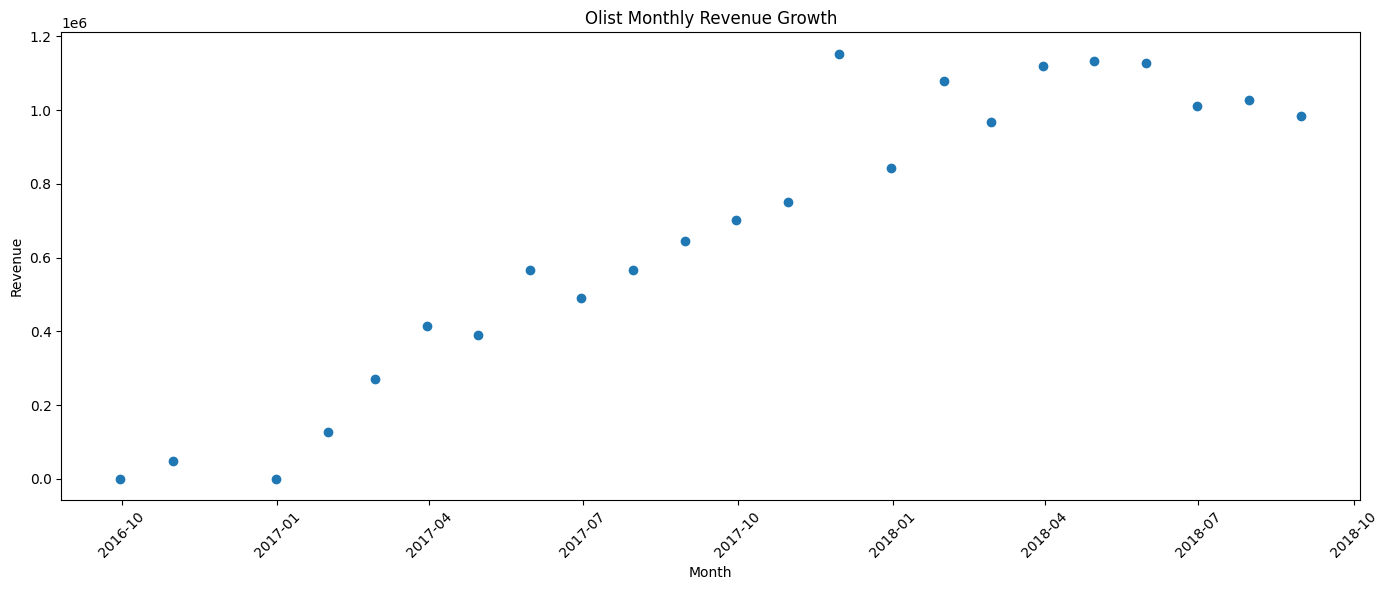

In [25]:
plt.figure(figsize=(14, 6))

plt.plot_date(
    month_revenue["month"],
    month_revenue["payment_value"]
)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Olist Monthly Revenue Growth")
plt.tight_layout()
plt.show()

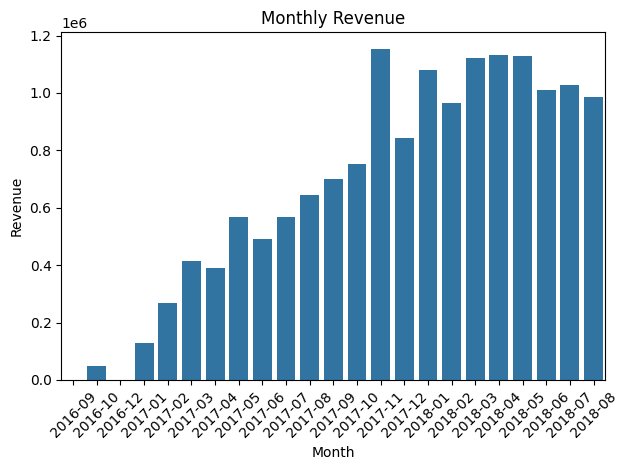

In [29]:
sns.barplot(
    data=month_revenue,
    x="month",
    y="payment_value"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Check the customer return

In [83]:
orders_customers = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [84]:
orders_customers

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...
96456,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
96457,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
96458,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
96459,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


In [87]:
orders_customers = orders_customers.dropna()
orders_customers = orders_customers.drop_duplicates()

In [96]:
orders_customers['customer_unique_id'].duplicated().sum()

np.int64(3119)

In [102]:
orders_per_customer = (
    orders_customers.groupby('customer_unique_id')['order_id'].nunique()
      .reset_index(name='number_of_orders')
)

print(orders_per_customer.shape)

(93342, 2)


In [99]:
orders_per_customer[orders_per_customer['number_of_orders']>1]

,customer_unique_id,number_of_orders
104,004288347e5e88a27ded2bb23747066c,2
243,00a39521eb40f7012db50455bf083460,2
305,00cc12a6d8b578b8ebd21ea4e2ae8b27,2
404,011575986092c30523ecb71ff10cb473,2
419,011b4adcd54683b480c4d841250a987f,2
...,...,...
92975,ff03923ad1eb9e32304deb7f9b2a45c9,2
93069,ff44401d0d8f5b9c54a47374eb48c1b8,2
93171,ff8892f7c26aa0446da53d01b18df463,2
93189,ff922bdd6bafcdf99cb90d7f39cea5b3,3


In [104]:
print((2800/93342)*100)

2.999721454436374


- Only 3% of customer has comeback 

## Check the customer experince by reviews

In [34]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [38]:
reviews["review_score"].value_counts()

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

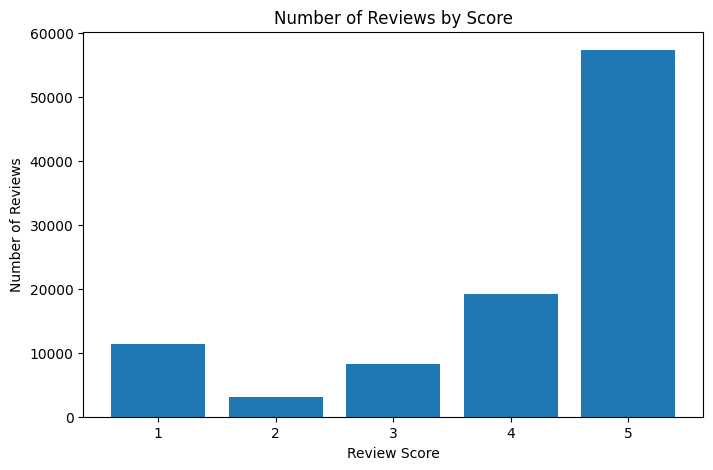

In [37]:
review_counts = reviews["review_score"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    review_counts.index,
    review_counts.values
)

plt.title("Number of Reviews by Score")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.xticks(review_counts.index)

plt.show()

In [64]:
orders_reviews = orders.merge(reviews, on='order_id', how='left')

In [40]:
orders_reviews

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96985,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,e262b3f92d1ce917aa412a9406cf61a6,5.0,NaN,NaN,2017-03-22 00:00:00,2017-03-23 11:02:08
96986,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,29bb71b2760d0f876dfa178a76bc4734,4.0,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01
96987,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,371579771219f6db2d830d50805977bb,5.0,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57
96988,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,8ab6855b9fe9b812cd03a480a25058a1,2.0,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56


In [65]:
orders_reviews = orders_reviews[['review_score', 'order_delivered_customer_date', 'order_estimated_delivery_date','order_approved_at']]

In [66]:
orders_reviews

,review_score,order_delivered_customer_date,order_estimated_delivery_date,order_approved_at
0,4.0,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10-02 11:07:15
1,4.0,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07-26 03:24:27
2,5.0,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08-08 08:55:23
3,5.0,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11-18 19:45:59
4,5.0,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02-13 22:20:29
...,...,...,...,...
96985,5.0,2017-03-17 15:08:01,2017-03-28 00:00:00,2017-03-09 09:54:05
96986,4.0,2018-02-28 17:37:56,2018-03-02 00:00:00,2018-02-06 13:10:37
96987,5.0,2017-09-21 11:24:17,2017-09-27 00:00:00,2017-08-27 15:04:16
96988,2.0,2018-01-25 23:32:54,2018-02-15 00:00:00,2018-01-08 21:36:21


In [67]:
orders_reviews["order_delivered_customer_date"] = pd.to_datetime(orders_reviews["order_delivered_customer_date"])
orders_reviews["order_estimated_delivery_date"] = pd.to_datetime(orders_reviews["order_estimated_delivery_date"])
orders_reviews["order_approved_at"] = pd.to_datetime(orders_reviews["order_approved_at"])

In [68]:
orders_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 96990 entries, 0 to 96989
Data columns (total 4 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   review_score                   96344 non-null  float64       
 1   order_delivered_customer_date  96990 non-null  datetime64[us]
 2   order_estimated_delivery_date  96990 non-null  datetime64[us]
 3   order_approved_at              96990 non-null  datetime64[us]
dtypes: datetime64[us](3), float64(1)
memory usage: 3.0 MB


In [69]:
orders_reviews = orders_reviews.dropna()
orders_reviews = orders_reviews.drop_duplicates()

In [74]:
orders_reviews['delivery_delay_days'] = (
    orders_reviews['order_delivered_customer_date'] -
    orders_reviews['order_approved_at']
).dt.total_seconds() / (60 * 60 * 24)

In [75]:
orders_reviews

,review_score,order_delivered_customer_date,order_estimated_delivery_date,order_approved_at,delivery_delay_days
0,4.0,2017-10-10 21:25:13,2017-10-18,2017-10-02 11:07:15,8.429144
1,4.0,2018-08-07 15:27:45,2018-08-13,2018-07-26 03:24:27,12.502292
2,5.0,2018-08-17 18:06:29,2018-09-04,2018-08-08 08:55:23,9.382708
3,5.0,2017-12-02 00:28:42,2017-12-15,2017-11-18 19:45:59,13.196331
4,5.0,2018-02-16 18:17:02,2018-02-26,2018-02-13 22:20:29,2.830938
...,...,...,...,...,...
96985,5.0,2017-03-17 15:08:01,2017-03-28,2017-03-09 09:54:05,8.218009
96986,4.0,2018-02-28 17:37:56,2018-03-02,2018-02-06 13:10:37,22.185637
96987,5.0,2017-09-21 11:24:17,2017-09-27,2017-08-27 15:04:16,24.847234
96988,2.0,2018-01-25 23:32:54,2018-02-15,2018-01-08 21:36:21,17.080938


In [78]:
cor = np.corrcoef(orders_reviews['review_score'], orders_reviews['delivery_delay_days'])

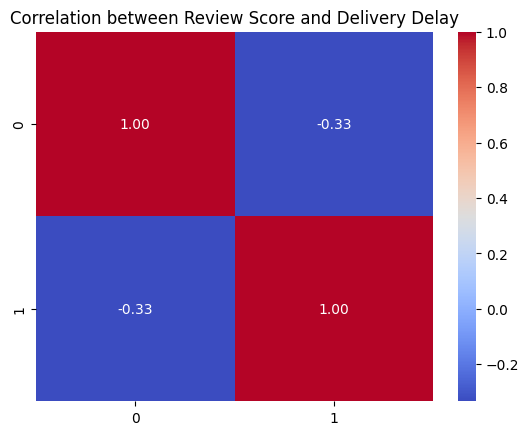

In [82]:
sns.heatmap(data=cor, annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation between Review Score and Delivery Delay')
plt.show()

- After Review the data
- There was good groth at last 2 years 
- But there was a customers churn with 97%
- There is a strong relation between the bad reveiws and the shipping days 

## How HVIA can help

- HVia can help Olist move from reactive logistics management to predictive customer-retention management.